# 2026 RTX Salary Analysis





## Context
Each year on reddit a survey is posted for RTX employees to submit their annual salary data

## Objective
practice using ML techniques on this data set to gain insight and to make salary predictions based on features.


## Data Description

The data consists of reddit users' submissions.

**Data Dictionary**

Timestamp: The date and time the survey response was submitted.

What business unit are you in?: The specific business unit or division the respondent belongs to (e.g., Raytheon, Collins Aerospace, Pratt and Whitney).
Were is your work location?: The physical or remote work location (e.g., Houston, Largo, Remote, etc.).

What is your pay grade?: The respondent's current pay grade level (e.g., P2, M4, T5, etc.).

What is your business function?: The department or functional area of the respondent (e.g., Engineering, Ops/Supply Chain, HR, etc.).

How many years of professional working experience do you have?: Total years of professional working experience (recorded in whole years).

How long have you been with the company?: Total years employed at the current company (recorded in whole years).

How long have you been in your current pay grade?: Total years the respondent has held their current pay grade (recorded in whole years).

Were you eligible for a merit increase this year?: Indicates whether the respondent was eligible for a merit-based base salary increase.

What was your merit increase percentage for 2026?: The percentage increase the respondent received for their 2026 merit raise.

What degrees do you hold?: The highest educational degrees held by the respondent (e.g., Bachelors, Masters).

What is your new salary after merit increase?: The respondent's updated annual base salary in dollars.

What was your annual bonus payout amount in dollars?: The total annual bonus amount received (recorded as 0 if not eligible).

How happy are you overall with your raise and bonus this year?: A satisfaction rating or statement regarding their recent compensation updates.

Comments: Any additional remarks, context, or feedback provided by the respondent.

Were you eligible for a bonus this year?: Indicates whether the respondent's position was eligible to receive an annual bonus.

## Importing necessary libraries and data

In [1]:
# import warnings
# warnings.filterwarnings("ignore")

# Libraries for data manipulation and visualization
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn.tree import DecisionTreeClassifier

from sklearn import tree

from sklearn.ensemble import RandomForestClassifier

# Metrics to evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from sklearn import metrics

# For hyperparameter tuning
from sklearn.model_selection import GridSearchCV

## Data Overview

- Observations
- Sanity checks

**Loading the data**

In [2]:
# load in the csv file from github repository
raw_github_url = "https://raw.githubusercontent.com/mikejoe144/RTX-Salary-data/main/2026salarydata.csv" # You will need to fill this in with the actual URL

try:
    data = pd.read_csv(raw_github_url)
    print("CSV file loaded successfully!")
except Exception as e:
    print(f"Error loading CSV file: {e}")
    print("Please ensure the URL is correct and points to a raw CSV file.")

CSV file loaded successfully!


In [3]:
# Copying data to another variable to avoid any changes to original data
df = data.copy()

**View first 5 rows**

In [4]:

df.head()


,Timestamp,What business unit are you in?,"Were is your work location? \r\n(e.g. Houston, Largo, Remote, etc.)","What is your pay grade? \r\n(P2, M4, T5, etc.)","What is your business function? \r\n(Engineering, Ops/Supply Chain, HR, etc.)",How many years of professional working experience do you have? \r\n(in whole years - round appropriately - <1 put 0),How long have you been with the company? \r\n(in whole years - round appropriately - <1 put 0),"How long have you been in your current pay grade? \r\n(in whole years, round appropriately - <1 put 0)",Were you eligible for a merit increase this year?,What was your merit increase percentage for 2026?\r\n (Answer as a percentage),What degrees do you hold?,What is your new salary after merit increase? \r\n(in dollars),What was your annual bonus payout amount in dollars?\r\n(if not eligible put 0),How happy are you overall with your raise and bonus this year?,Comments \r\n(say anything you'd like),Were you eligible for a bonus this year?
0,2/22/2026 22:33:56,Raytheon,"Honolulu, HI",P3,Mission Intelligence,12.0,1.0,1.0,Yes,3.0,"Bachelors, Masters",133900.0,5200.0,3 - Ambivalent,NaN,Yes
1,2/23/2026 4:49:14,Raytheon,UK,M4,EHS,23.0,12.0,4.0,Yes,3.5,Bachelors,97000.0,14200.0,4 - Happy,NaN,Yes
2,2/23/2026 5:37:03,Pratt and Whitney,Hybrid,P2,Ops,NaN,4.0,1.0,Yes,3.0,Masters,97000.0,0.0,3 - Ambivalent,NaN,No - my position is not eligible for a bonus
3,2/23/2026 6:54:23,Collins Aerospace,Puerto Rico,P3,Software,3.0,0.0,0.0,Yes,1.0,"Bachelors, Masters",80800.0,0.0,3 - Ambivalent,NaN,No - my position is not eligible for a bonus
4,2/23/2026 7:02:41,Other (e.g.) corporate,Remote,P1,Supply Chain,4.0,0.0,0.0,Yes,3.0,Masters,85490.0,0.0,3 - Ambivalent,NaN,No - my position is not eligible for a bonus


**Checking Info of data**

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 16 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   Timestamp                                                                                                           860 non-null    object 
 1   What business unit are you in?                                                                                      860 non-null    object 
 2   Were is your work location? 
(e.g. Houston, Largo, Remote, etc.)                                                   828 non-null    object 
 3   What is your pay grade? 
(P2, M4, T5, etc.)                                                                        854 non-null    object 
 4   What is your business 

### Checking for missing values

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64


### Checking for duplicate rows

In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


### Displaying descriptive statistics

In [ ]:
display(df.describe(include='all'))

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
count,4612,4612.000000,4612,4612,4612,4612.000000,4612.000000,4612.000000,4612,4612,4612,4612,4612,4612,4612.000000
unique,4612,NaN,3,2,3,NaN,NaN,NaN,3,2,2,2,2,2,NaN
top,EXT4612,NaN,Professional,Website,High,NaN,NaN,NaN,Email Activity,No,No,No,No,No,NaN
freq,1,NaN,2616,2542,2264,NaN,NaN,NaN,2278,4115,4379,4085,3907,4519,NaN
mean,NaN,46.201214,NaN,NaN,NaN,3.566782,724.011275,3.026126,NaN,NaN,NaN,NaN,NaN,NaN,0.298569
std,NaN,13.161454,NaN,NaN,NaN,2.829134,743.828683,1.968125,NaN,NaN,NaN,NaN,NaN,NaN,0.457680
min,NaN,18.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,36.000000,NaN,NaN,NaN,2.000000,148.750000,2.077750,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,51.000000,NaN,NaN,NaN,3.000000,376.000000,2.792000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,57.000000,NaN,NaN,NaN,5.000000,1336.750000,3.756250,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


In [ ]:
# Selecting numerical columns and checking the summary statistics
num_cols = df.select_dtypes('number').columns

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


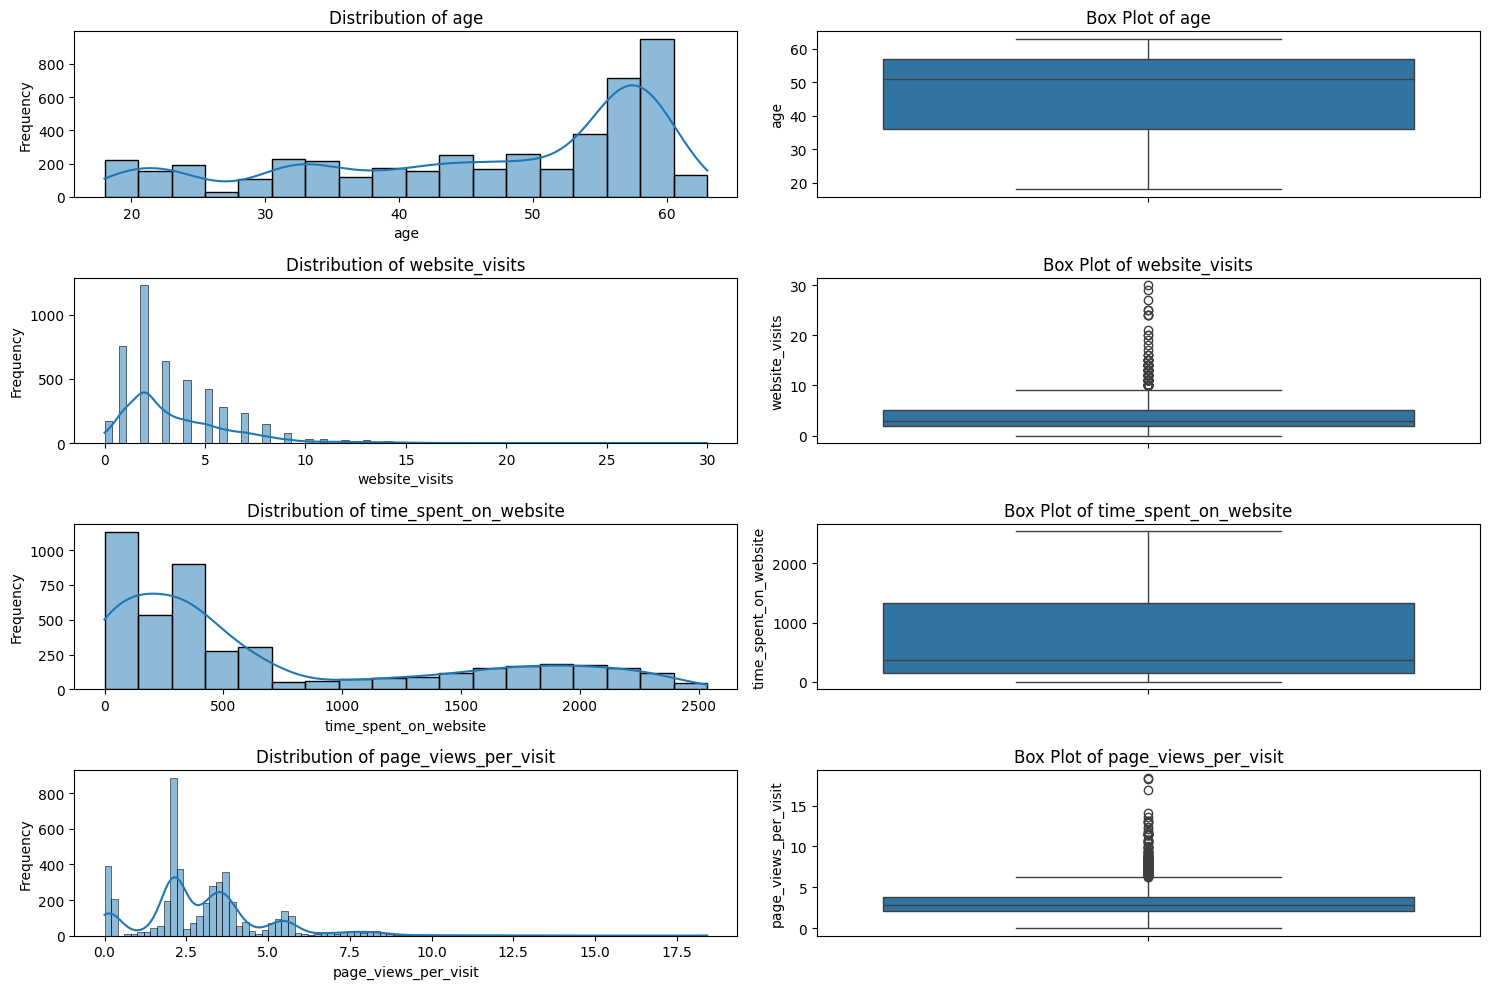

In [ ]:
# Select numerical columns excluding 'status'
num_cols_for_hist = df.select_dtypes(include=np.number).columns.tolist()
if 'status' in num_cols_for_hist:
    num_cols_for_hist.remove('status')

# Loop through the selected numerical columns and plot histograms and boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_for_hist):
    plt.subplot(len(num_cols_for_hist), 2, i*2 + 1) # Histogram
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(len(num_cols_for_hist), 2, i*2 + 2) # Boxplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Observations:

*   age distribution is left skewed, majority of leads are mid career
*   website visits are right skewed, there are some extremes of people visiting 30 times, but the average is 2-5
*   time spent on the website is right skewed, with a wide range of time
*   most people only visit 2-4 pages



what is the percentage of converted vs not convert in the data set?

In [ ]:
df['status'].value_counts(normalize=True)

,proportion
status,
0,0.701431
1,0.298569


about 30% of the data set population converted into customers. this may come in handy later when tuning.

**descriptive analysis of numeric features for conversions**

Descriptive statistics for numerical columns when status = 1:


,count,mean,std,min,25%,50%,75%,max
age,1377.0,48.663762,11.293692,18.0,41.000,54.000,58.00,63.000
website_visits,1377.0,3.538126,2.721075,0.0,2.000,3.000,5.00,25.000
time_spent_on_website,1377.0,1068.397967,780.856643,0.0,390.000,789.000,1829.00,2537.000
page_views_per_visit,1377.0,3.027050,1.896893,0.0,2.083,2.935,3.73,13.656


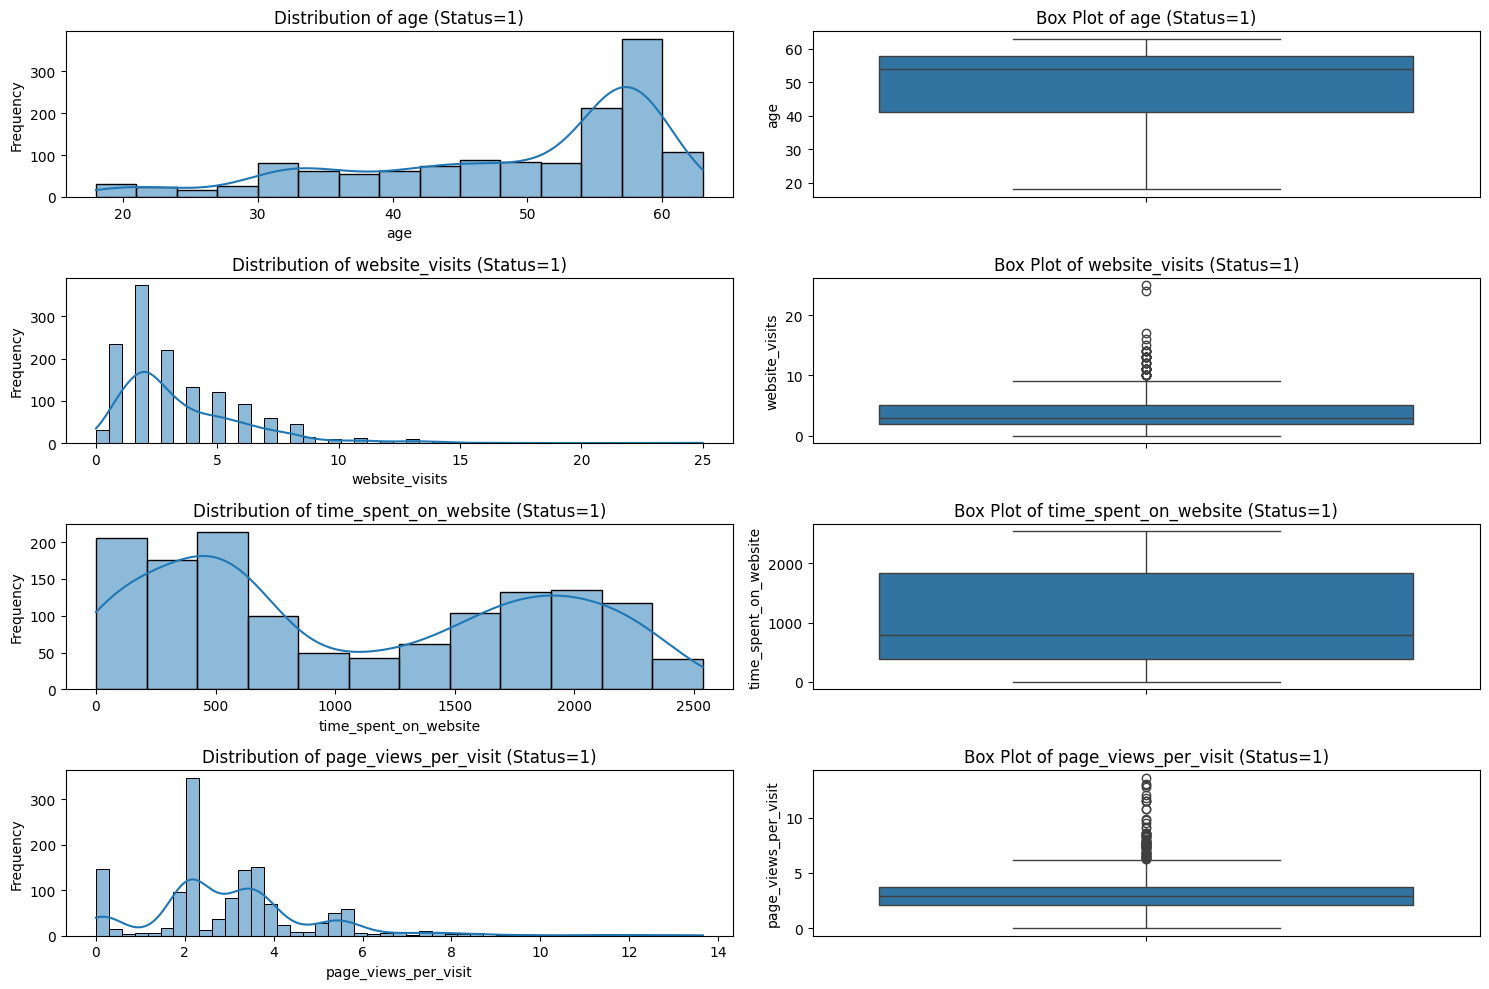

In [ ]:
# Filter the DataFrame for status = 1 (converted leads)
df_converted = df[df['status'] == 1]

# Select numerical columns excluding 'status' (as it's already filtered to 1)
num_cols_for_analysis = df_converted.select_dtypes(include=np.number).columns.tolist()
if 'status' in num_cols_for_analysis:
    num_cols_for_analysis.remove('status')

print("Descriptive statistics for numerical columns when status = 1:")
display(df_converted[num_cols_for_analysis].describe().T)

# Loop through the selected numerical columns and plot histograms and boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_for_analysis):
    plt.subplot(len(num_cols_for_analysis), 2, i*2 + 1) # Histogram
    sns.histplot(df_converted[col], kde=True)
    plt.title(f'Distribution of {col} (Status=1)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(len(num_cols_for_analysis), 2, i*2 + 2) # Boxplot
    sns.boxplot(y=df_converted[col])
    plt.title(f'Box Plot of {col} (Status=1)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Observations

*   most of the conversions are people that are mid 50s. not a lot of the prospects under 30 lead to conversions.
*   spending over 1000 (seconds?) on the website appears to signal someone who will result in a conversion. this could be tied to people who spent more time creating their profile as we saw that leads to more conversions.



## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

**does the current occupation affect lead status?**

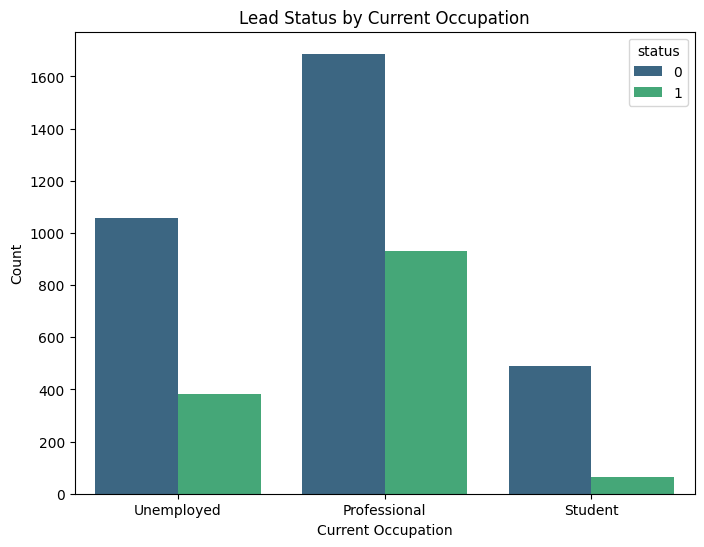

status,0,1
current_occupation,,
Professional,0.64,0.36
Student,0.88,0.12
Unemployed,0.73,0.27


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='current_occupation', hue='status', palette='viridis')
plt.title('Lead Status by Current Occupation')
plt.xlabel('Current Occupation')
plt.ylabel('Count')
plt.show()

# Also show conversion rates by occupation
occupation_status = df.groupby('current_occupation')['status'].value_counts(normalize=True).unstack()
display(occupation_status.round(2))

it appears that being a professional results in the most amount of converted leads. 36% of the professions convert to leads, 27% of the unemployed and 12% of the students.

**Did the first interaction seem to affect conversions?**

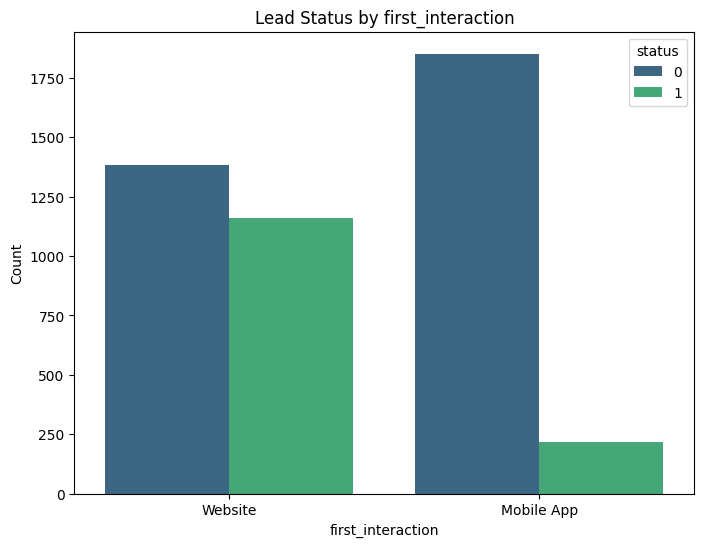

status,0,1
first_interaction,,
Mobile App,0.89,0.11
Website,0.54,0.46


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='first_interaction', hue='status', palette='viridis')
plt.title('Lead Status by first_interaction')
plt.xlabel('first_interaction')
plt.ylabel('Count')
plt.show()

# Also show conversion rates by occupation
occupation_status = df.groupby('first_interaction')['status'].value_counts(normalize=True).unstack()
display(occupation_status.round(2))

It appears that more people's first interaction is through a website and that the websites lead to more conversions

**Does the method of interaction with the prospects matter?**

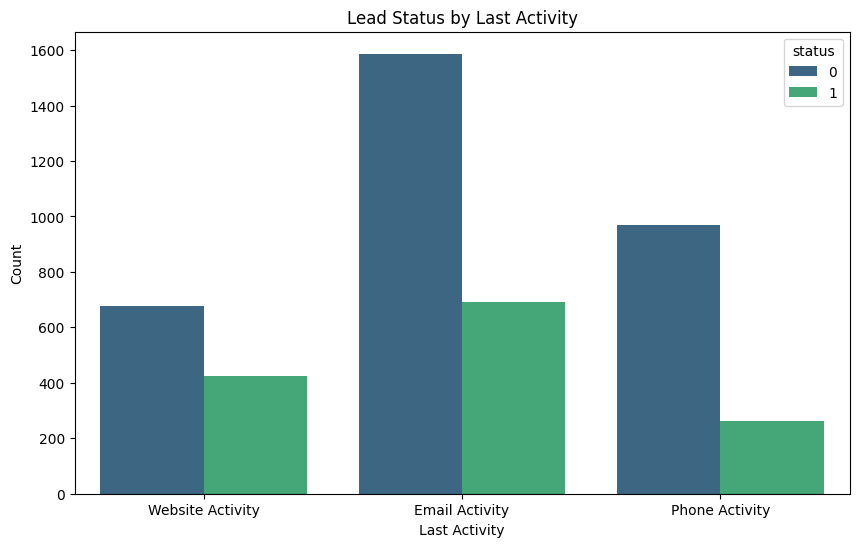

status,0,1
last_activity,,
Email Activity,0.70,0.30
Phone Activity,0.79,0.21
Website Activity,0.62,0.38


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='last_activity', hue='status', palette='viridis')
plt.title('Lead Status by Last Activity')
plt.xlabel('Last Activity')
plt.ylabel('Count')
plt.show()

# Calculate and display conversion rates by last activity
last_activity_status = df.groupby('last_activity')['status'].value_counts(normalize=True).unstack()
display(last_activity_status.round(2))

it appears that website activity has the best rate for conversions 38%, and phone activity is the least success rate of conversions 21%. email activity is the most common activity though and has the most amount of conversions through emails, ~700 conversions.

### 4. Which advertising channels have the highest lead conversion rate?

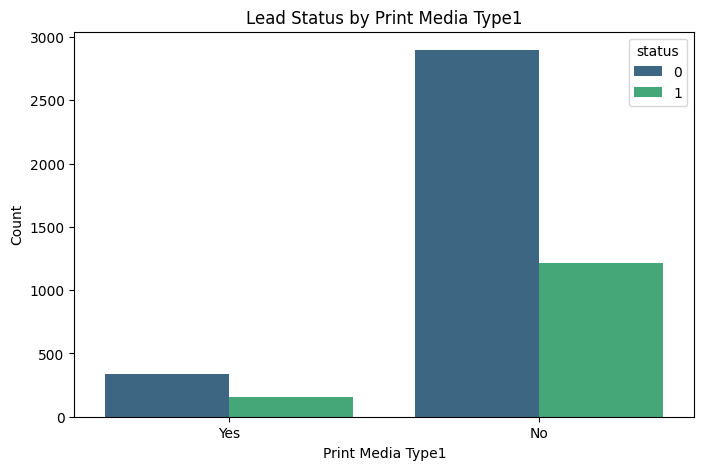

Conversion rates for Print Media Type1:


status,0,1
print_media_type1,,
No,0.70,0.30
Yes,0.68,0.32



--------------------------------------------------



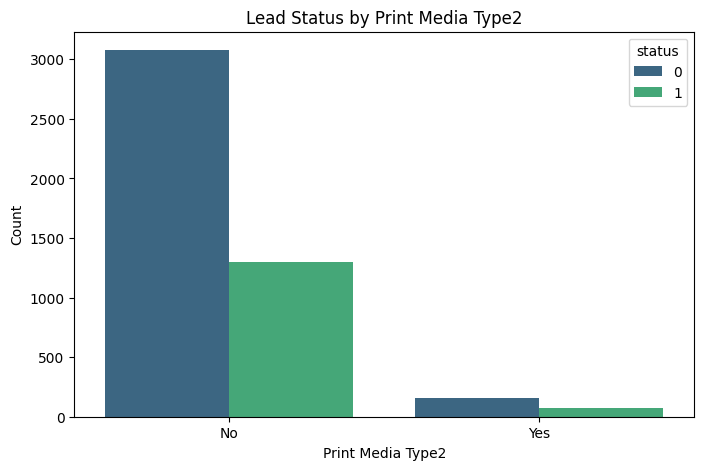

Conversion rates for Print Media Type2:


status,0,1
print_media_type2,,
No,0.70,0.30
Yes,0.68,0.32



--------------------------------------------------



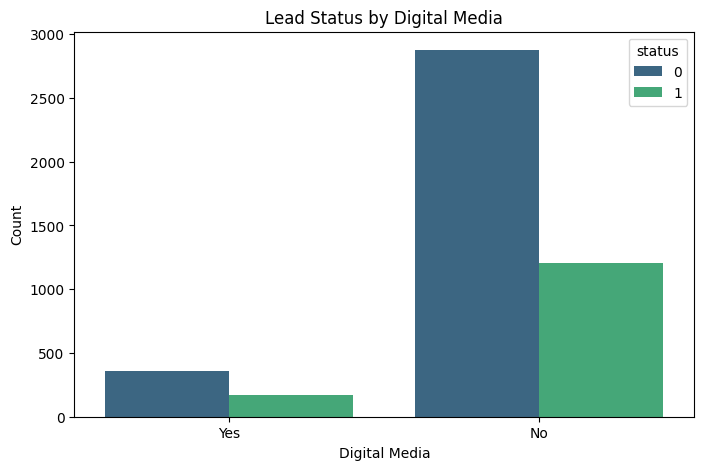

Conversion rates for Digital Media:


status,0,1
digital_media,,
No,0.70,0.30
Yes,0.68,0.32



--------------------------------------------------



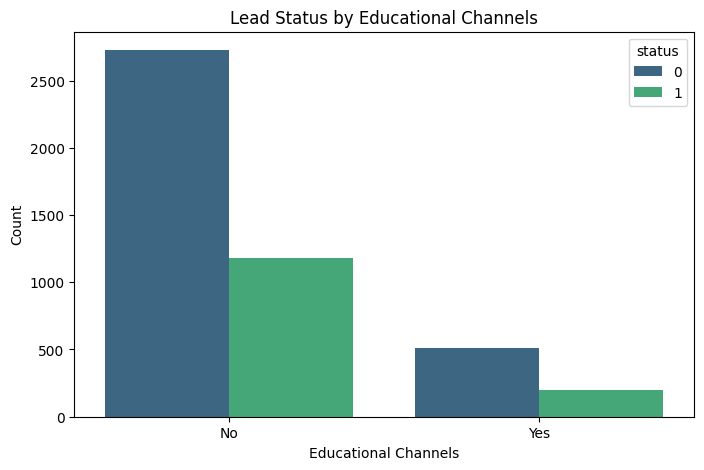

Conversion rates for Educational Channels:


status,0,1
educational_channels,,
No,0.70,0.30
Yes,0.72,0.28



--------------------------------------------------



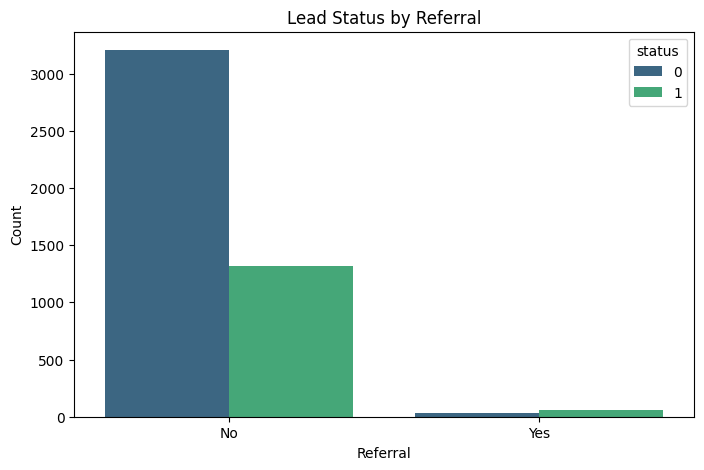

Conversion rates for Referral:


status,0,1
referral,,
No,0.71,0.29
Yes,0.32,0.68



--------------------------------------------------



In [ ]:

media_channels = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

for channel in media_channels:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=channel, hue='status', palette='viridis')
    plt.title(f'Lead Status by {channel.replace("_", " ").title()}')
    plt.xlabel(channel.replace("_", " ").title())
    plt.ylabel('Count')
    plt.show()

    conversion_rate = df.groupby(channel)['status'].value_counts(normalize=True).unstack()
    print(f"Conversion rates for {channel.replace('_', ' ').title()}:")
    display(conversion_rate.round(2))
    print("\n" + "-"*50 + "\n")


referals had the highest rate of conversion at 68%. in terms of most conversions in total, education channels had the highest.  

**People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?**

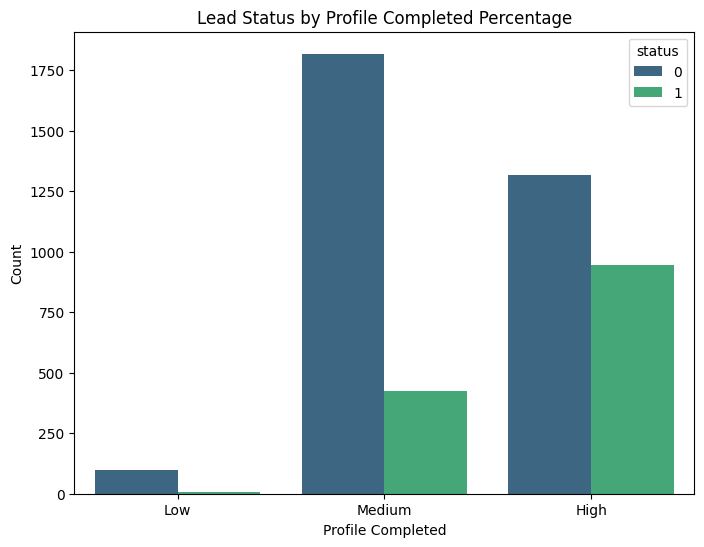

status,0,1
profile_completed,,
High,0.58,0.42
Low,0.93,0.07
Medium,0.81,0.19


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='profile_completed', hue='status', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Lead Status by Profile Completed Percentage')
plt.xlabel('Profile Completed')
plt.ylabel('Count')
plt.show()

# Calculate and display conversion rates by profile completed status
profile_completed_status = df.groupby('profile_completed')['status'].value_counts(normalize=True).unstack()
display(profile_completed_status.round(2))

it appears that people who have spent more time completing their profile were more likely to convert.

**pairwise correlations between all the numerical variables.**

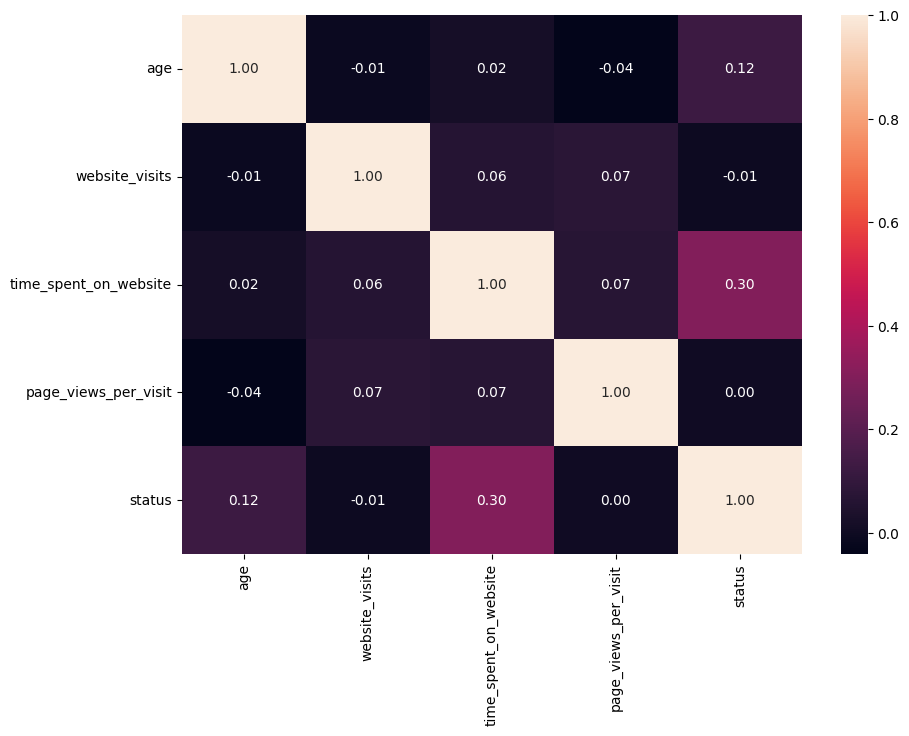

In [ ]:
plt.figure(figsize=(10, 7))

# Select only the numeric columns
numeric_data = df.select_dtypes(include='number')

# Plot the heatmap
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f")

plt.show()

of the numerical features, time spent on website has the highest correlation to conversions

## Preprocessing for Correlation Matrix

### Subtask:
Convert categorical features to numerical format using one-hot encoding and drop the 'ID' column. This prepares the data for correlation analysis.


**Reasoning**:
To prepare the data for correlation analysis, I will first create a copy of the dataframe, then identify categorical columns and apply one-hot encoding, and finally drop the original categorical columns and the 'ID' column as instructed.



In [ ]:
df_processed = df.copy()

# Drop the 'ID' column as it's not needed for correlation and is not a feature
df_processed = df_processed.drop('ID', axis=1)

# Identify all categorical columns
categorical_cols_for_dummies = df_processed.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding WITHOUT dropping the first category
df_processed = pd.get_dummies(df_processed, columns=categorical_cols_for_dummies, dtype=int)

print("Shape of df_processed after one-hot encoding:", df_processed.shape)
print("First 5 rows of df_processed:")
display(df_processed.head())

Shape of df_processed after one-hot encoding: (4612, 26)
First 5 rows of df_processed:


,age,website_visits,time_spent_on_website,page_views_per_visit,status,current_occupation_Professional,current_occupation_Student,current_occupation_Unemployed,first_interaction_Mobile App,first_interaction_Website,...,print_media_type1_No,print_media_type1_Yes,print_media_type2_No,print_media_type2_Yes,digital_media_No,digital_media_Yes,educational_channels_No,educational_channels_Yes,referral_No,referral_Yes
0,57,7,1639,1.861,1,0,0,1,0,1,...,0,1,1,0,0,1,1,0,1,0
1,56,2,83,0.320,0,1,0,0,1,0,...,1,0,1,0,1,0,0,1,1,0
2,52,3,330,0.074,0,1,0,0,0,1,...,1,0,1,0,0,1,1,0,1,0
3,53,4,464,2.057,1,0,0,1,0,1,...,1,0,1,0,1,0,1,0,1,0
4,23,4,600,16.914,0,0,1,0,0,1,...,1,0,1,0,1,0,1,0,1,0


**Reasoning**:
Now that the data has been preprocessed with one-hot encoding and the 'ID' column dropped, the next step is to calculate the correlation matrix, specifically focusing on the 'status' column to identify features most correlated with conversions, and then visualize it using a heatmap.



Correlations with 'status':


,status
status,1.000000
first_interaction_Website,0.381077
time_spent_on_website,0.302100
profile_completed_High,0.255933
current_occupation_Professional,0.141476
age,0.122084
referral_Yes,0.118761
last_activity_Website Activity,0.105144
educational_channels_No,0.017763
print_media_type1_Yes,0.016214


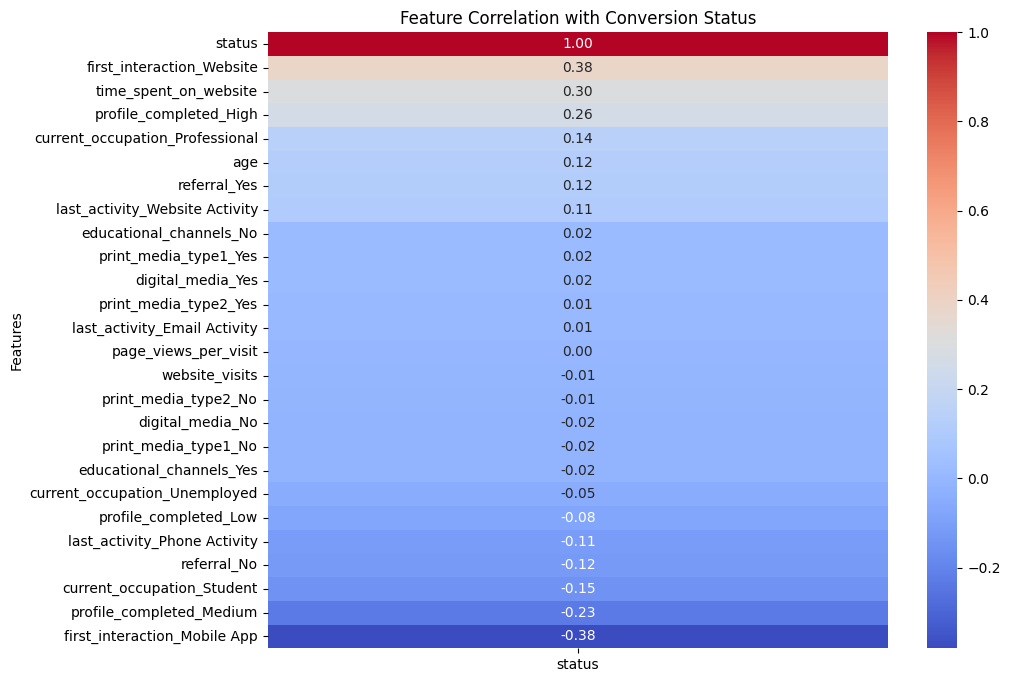

In [ ]:
correlation_matrix = df_processed.corr()

# Sort the correlations with 'status' in descending order
status_correlations = correlation_matrix['status'].sort_values(ascending=False)
print("Correlations with 'status':")
display(status_correlations)

# Visualize the correlation matrix focusing on 'status'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['status']].sort_values(by='status', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Conversion Status')
plt.ylabel('Features')
plt.show()



*   The feature `first_interaction_Website` showed the strongest positive correlation with conversion status (approximately 0.381).
*   `time_spent_on_website` also exhibited a notable positive correlation with conversion status (approximately 0.302).
*   Conversely, `profile_completed_Medium` showed the most significant negative correlation with conversion status (approximately -0.233).
why is `profile_completed_Medium` have a more negative correlation than `profile_completed_Low`? i would have thought it would be switched.
*   `current_occupation_Student` also had a negative correlation with conversion status (approximately -0.147).


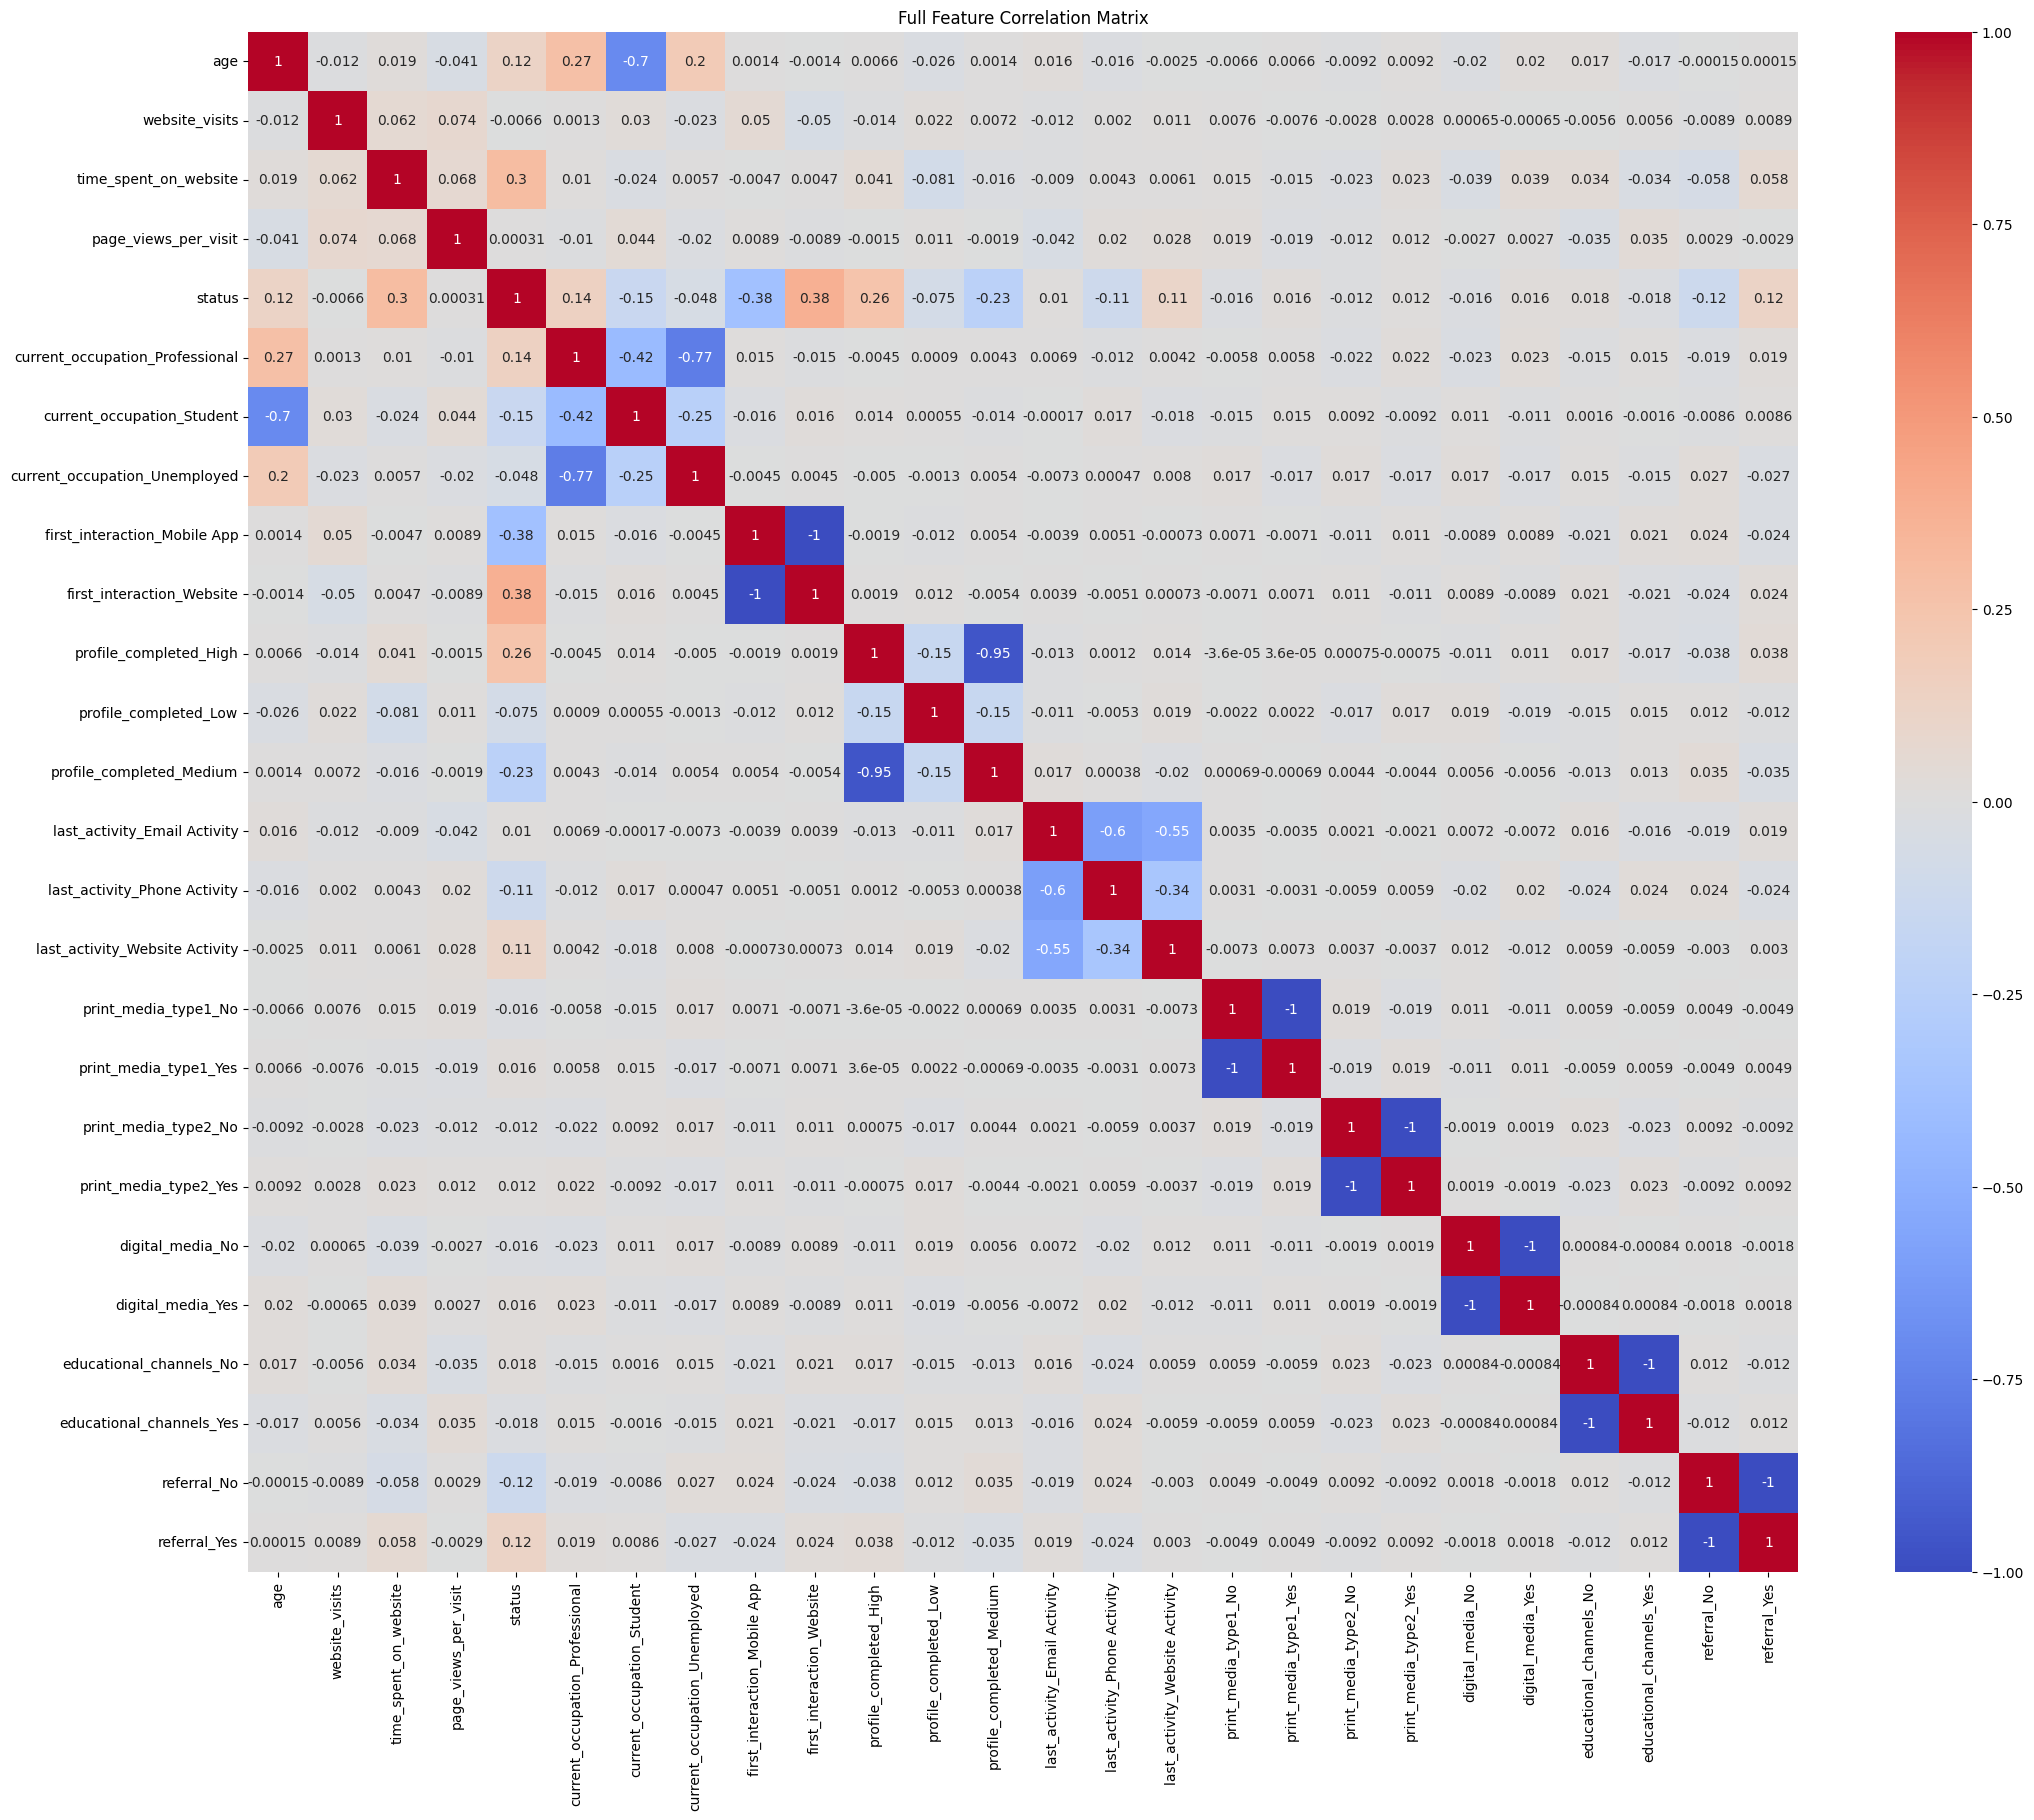

In [ ]:
plt.figure(figsize=(25,20))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=True)
plt.title('Full Feature Correlation Matrix')
plt.show()

age is negatively correlated to being a student which makes sense, younger are more likely college age. the older you are the more likely you are unemployed or a proffesional

## Data Preprocessing

- Missing value treatment (no, no missing values)
- Feature engineering (yes, one hot encoding)
- Outlier detection and treatment (not needed in decision tree)
- Preparing data for modeling (train/test split)
- Any other preprocessing steps (if needed)

In a decision tree

*   they are not sensitive to outliers
*   scaling/normalization is not needed
*  trees can handle correlated features fine




**Are there missing values?**

In [ ]:
df.isnull().values.any()

np.False_

no missing values to treat

feature engineering

In [ ]:
# Create a copy of the original DataFrame for feature engineering
df_fe = df.copy()

# Drop the 'ID' column as it's not a feature
df_fe = df_fe.drop('ID', axis=1)

# Separate numerical columns from categorical
numerical_cols = df_fe.select_dtypes(include=np.number).columns.tolist()
# Remove 'status' from numerical_cols if it's there, as it's our target variable and already 0/1
if 'status' in numerical_cols:
    numerical_cols.remove('status')

categorical_cols = df_fe.select_dtypes(include='object').columns.tolist()

# Identify binary and non-binary categorical columns
binary_categorical_cols = []
non_binary_categorical_cols = []

for col in categorical_cols:
    if df_fe[col].nunique() == 2:
        binary_categorical_cols.append(col)
    else:
        non_binary_categorical_cols.append(col)

print(f"Binary categorical columns: {binary_categorical_cols}")
print(f"Non-binary categorical columns: {non_binary_categorical_cols}")

# Apply one-hot encoding to non-binary categorical columns (keep all categories)
# Example: profile_completed will become profile_completed_High, profile_completed_Low, profile_completed_Medium
df_non_binary_encoded = pd.get_dummies(df_fe[non_binary_categorical_cols],
                                       columns=non_binary_categorical_cols,
                                       prefix=non_binary_categorical_cols,
                                       drop_first=False,
                                       dtype=int)

# Apply one-hot encoding to binary categorical columns (drop one category to have 0/1)
# Example: first_interaction will become first_interaction_Website (0 for Mobile App, 1 for Website)
df_binary_encoded = pd.get_dummies(df_fe[binary_categorical_cols],
                                   columns=binary_categorical_cols,
                                   prefix=binary_categorical_cols,
                                   drop_first=True, # Drop one category
                                   dtype=int)

# Combine all processed features
# Start with numerical columns and the original 'status' column
df_processed_fe = pd.concat([df_fe[numerical_cols], df_fe['status'],
                           df_non_binary_encoded, df_binary_encoded], axis=1)

print("\nShape of the DataFrame after feature engineering:", df_processed_fe.shape)
print("First 5 rows of the DataFrame after feature engineering:")
display(df_processed_fe.head())

# Store this processed DataFrame in a new variable, e.g., 'df_model' for clarity in subsequent modeling steps
df_model = df_processed_fe

Binary categorical columns: ['first_interaction', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
Non-binary categorical columns: ['current_occupation', 'profile_completed', 'last_activity']

Shape of the DataFrame after feature engineering: (4612, 20)
First 5 rows of the DataFrame after feature engineering:


,age,website_visits,time_spent_on_website,page_views_per_visit,status,current_occupation_Professional,current_occupation_Student,current_occupation_Unemployed,profile_completed_High,profile_completed_Low,profile_completed_Medium,last_activity_Email Activity,last_activity_Phone Activity,last_activity_Website Activity,first_interaction_Website,print_media_type1_Yes,print_media_type2_Yes,digital_media_Yes,educational_channels_Yes,referral_Yes
0,57,7,1639,1.861,1,0,0,1,1,0,0,0,0,1,1,1,0,1,0,0
1,56,2,83,0.320,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0
2,52,3,330,0.074,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0
3,53,4,464,2.057,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0
4,23,4,600,16.914,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0


converted binary categorial features into 0/1 and non binary categorical using one hot encoding

**build train and test data sets**

In [ ]:
X = df_model.drop('status', axis=1)
y = df_model['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Building a Decision Tree model

Before training the model, let's choose the appropriate model evaluation criterion as per the problem at hand.

the objective of the model is to predict who is potentially going to convert. it is alright if we are incorrect in thinking someone will convert but they don't but it is worse if we miss someone who we thought wasn't going to convert but did. in other words, we don't want to miss good leads as we will lose a potential paying customer.
*   True positive = correctly guessing a converted customer
*   false positive = predicted customer but they weren't, wasted sales effort
*   false negative = we didn't think they would convert, but they would have, lost customer
*   true negative = correclty predicted they aren't a potential customer and didn't waste our efforts.



we want to maximize true positives and minimize false negatives so we care about maximizing the recall in this problem. to minimize wasted sales effort we want to try and maximize precision. since we care about precision and recall we should use F1 score to as a secondary score to evaluate our model.



Score priorities:
1.   Recall
2.   F1



**Function to print classification report and get confusion matrix in a proper format**

In [ ]:
# Function to print classification report and get confusion matrix in a proper format
from sklearn.metrics import accuracy_score


def metrics_score(actual, predicted):

    print("Accuracy:", accuracy_score(actual, predicted))
    print("\nClassification Report:\n")
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(8,5))

    cm = confusion_matrix(actual, predicted, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not Converted','Converted'],
            yticklabels=['Not Converted','Converted'])

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title("Confusion Matrix")

    plt.show()



**Decision Tree**

In [ ]:
# Fitting the decision tree classifier on the training data
d_tree =  DecisionTreeClassifier(random_state = 13)

d_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=13)

## Model Performance evaluation and improvement

Accuracy: 0.9997289238275956

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2588
           1       1.00      1.00      1.00      1101

    accuracy                           1.00      3689
   macro avg       1.00      1.00      1.00      3689
weighted avg       1.00      1.00      1.00      3689



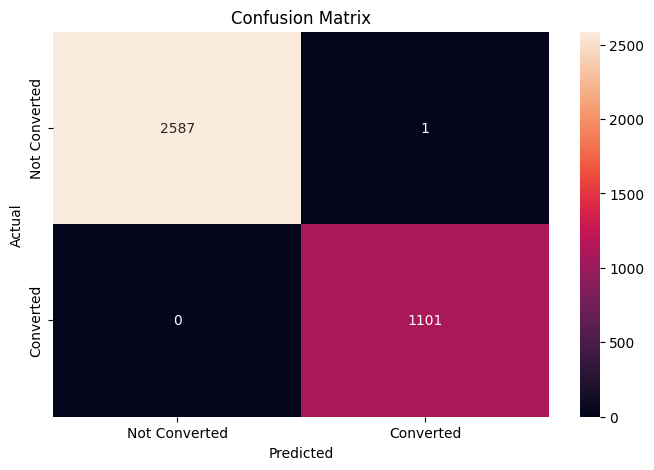

In [ ]:
y_pred_train1 = d_tree.predict(X_train)

metrics_score(y_train, y_pred_train1)

such a high level of accuracy, most likely means there was overfitting. let us use the test data next to confirm this

Accuracy: 0.80931744312026

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       647
           1       0.68      0.70      0.69       276

    accuracy                           0.81       923
   macro avg       0.77      0.78      0.77       923
weighted avg       0.81      0.81      0.81       923



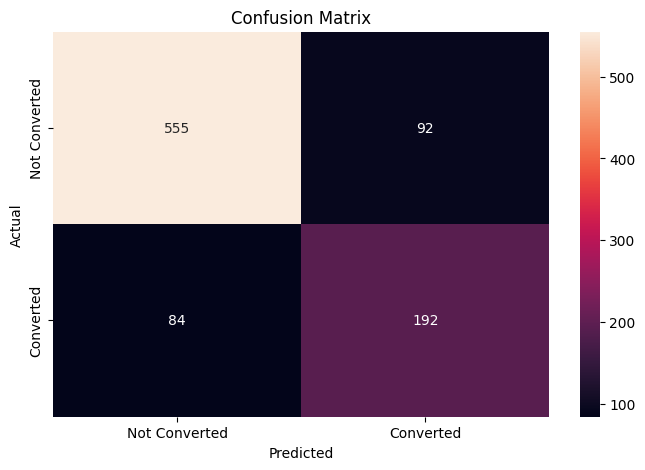

In [ ]:
# Checking performance on the testing data
y_pred_test1 = d_tree.predict(X_test)

metrics_score(y_test, y_pred_test1)

performance went down, as was suspected there was overfitting on the training data. time to do some tuning and evaluating it based on recall.

In [ ]:
from sklearn.metrics import recall_score
# Choose the type of classifier
d_tree_tuned = DecisionTreeClassifier(random_state = 7, class_weight = {0: 0.3, 1: 0.7})

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25],
              'min_samples_split':[10,20,50]
             }

# Type of scoring used to compare parameter combinations - f1 score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(3), min_samples_leaf=5,
                       min_samples_split=10, random_state=7)

Accuracy: 0.7888316616969369

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.74      0.83      2588
           1       0.60      0.91      0.72      1101

    accuracy                           0.79      3689
   macro avg       0.77      0.82      0.77      3689
weighted avg       0.84      0.79      0.80      3689



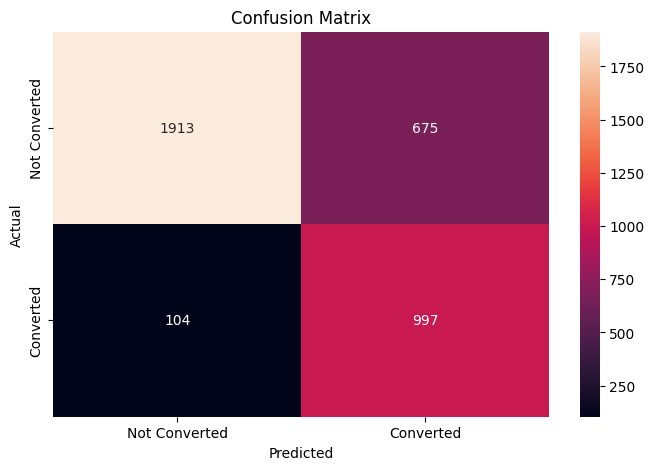

In [ ]:
# Checking performance on the training data
y_pred_train2 = d_tree_tuned.predict(X_train)

metrics_score(y_train, y_pred_train2)

Accuracy: 0.7919826652221018

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.75      0.84       647
           1       0.60      0.88      0.72       276

    accuracy                           0.79       923
   macro avg       0.77      0.82      0.78       923
weighted avg       0.84      0.79      0.80       923



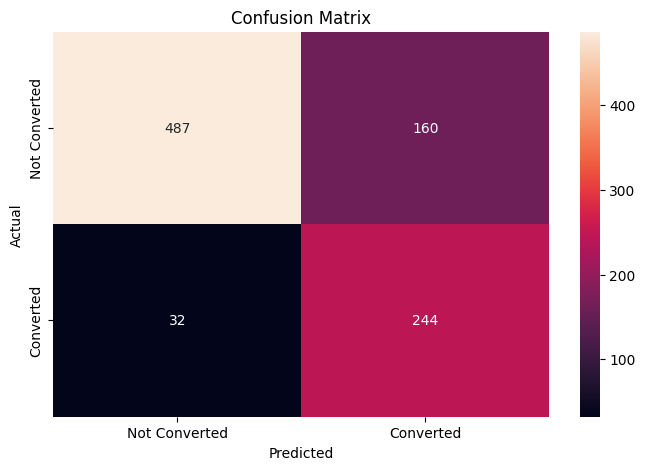

In [ ]:
y_pred_test2 = d_tree_tuned.predict(X_test)

metrics_score(y_test, y_pred_test2)

**Take 2: let's further tune to try and get a better recall score**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# Step 1: Define the classifier
# Use 'balanced' so the tree automatically adjusts weights for class imbalance
d_tree = DecisionTreeClassifier(random_state=7, class_weight = {0: 0.3, 1: 0.7})

# Step 2: Define the grid of hyperparameters to tune
parameters = {
    'max_depth': np.arange(2, 15),            # try deeper trees
    'min_samples_leaf': [5, 10, 20, 25],      # prevent tiny leaves
    'min_samples_split': [10, 20, 50],        # control splits
    'max_features': [None, 'sqrt', 'log2']    # try different feature subsets
}

# Step 3: Define the scoring metric
# We care about catching as many converters as possible → use recall for class 1
scorer = make_scorer(recall_score, pos_label=1)

# Step 4: Set up GridSearchCV with 5-fold stratified CV
grid_obj = GridSearchCV(d_tree, parameters, scoring=scorer, cv=5, n_jobs=-1)  # n_jobs=-1 uses all cores

# Step 5: Fit grid search to the training data
grid_obj.fit(X_train, y_train)

# Step 6: Extract the best estimator
d_tree_tuned2 = grid_obj.best_estimator_

# Step 7: (Optional) Fit the best model again
d_tree_tuned2.fit(X_train, y_train)


DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, max_depth=np.int64(4),
                       max_features='sqrt', min_samples_leaf=5,
                       min_samples_split=10, random_state=7)

Accuracy: 0.6782325833559231

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.57      0.71      2588
           1       0.48      0.94      0.64      1101

    accuracy                           0.68      3689
   macro avg       0.72      0.75      0.67      3689
weighted avg       0.81      0.68      0.69      3689



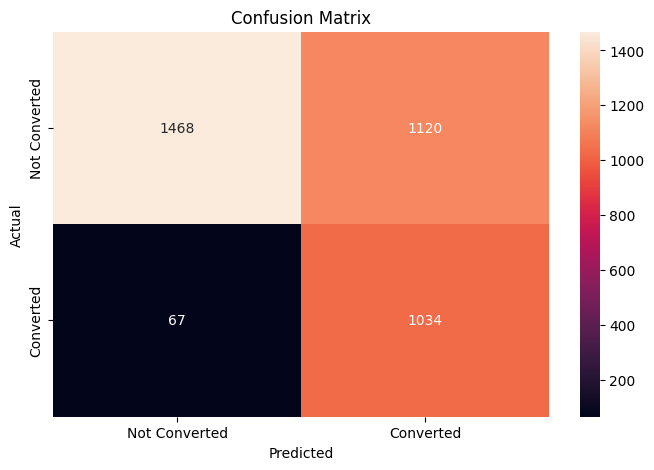

In [ ]:
# Checking performance on the training data
y_pred_train3 = d_tree_tuned2.predict(X_train)

metrics_score(y_train, y_pred_train3)

Accuracy: 0.6803900325027086

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.58      0.72       647
           1       0.48      0.92      0.63       276

    accuracy                           0.68       923
   macro avg       0.71      0.75      0.67       923
weighted avg       0.81      0.68      0.69       923



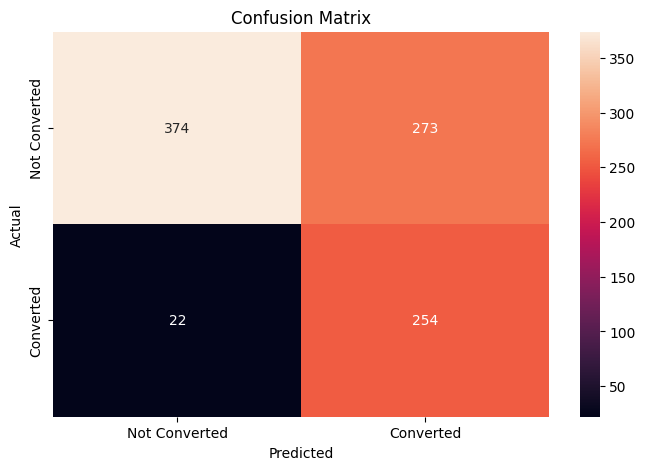

In [ ]:
y_pred_test3 = d_tree_tuned2.predict(X_test)

metrics_score(y_test, y_pred_test3)

The first tuned model had a recall and F1 score of 0.88 and 0.72 on the test data on guessing converted customers. the second tuned model had a recall and F1 score of 0.92 and 0.63 on the test data on guessing converted customers. although the second tuned model had a higher recall the F1 score dropped significantly. let's assume because this is an initial stage start up our customer acquisition cost is on the higher side, therefore we would value the F1 score more than let's say a bigger company that has a lower CAC because it is more costly to us to predict false positives.

let's pick this as the better model:
`d_tree_tuned`

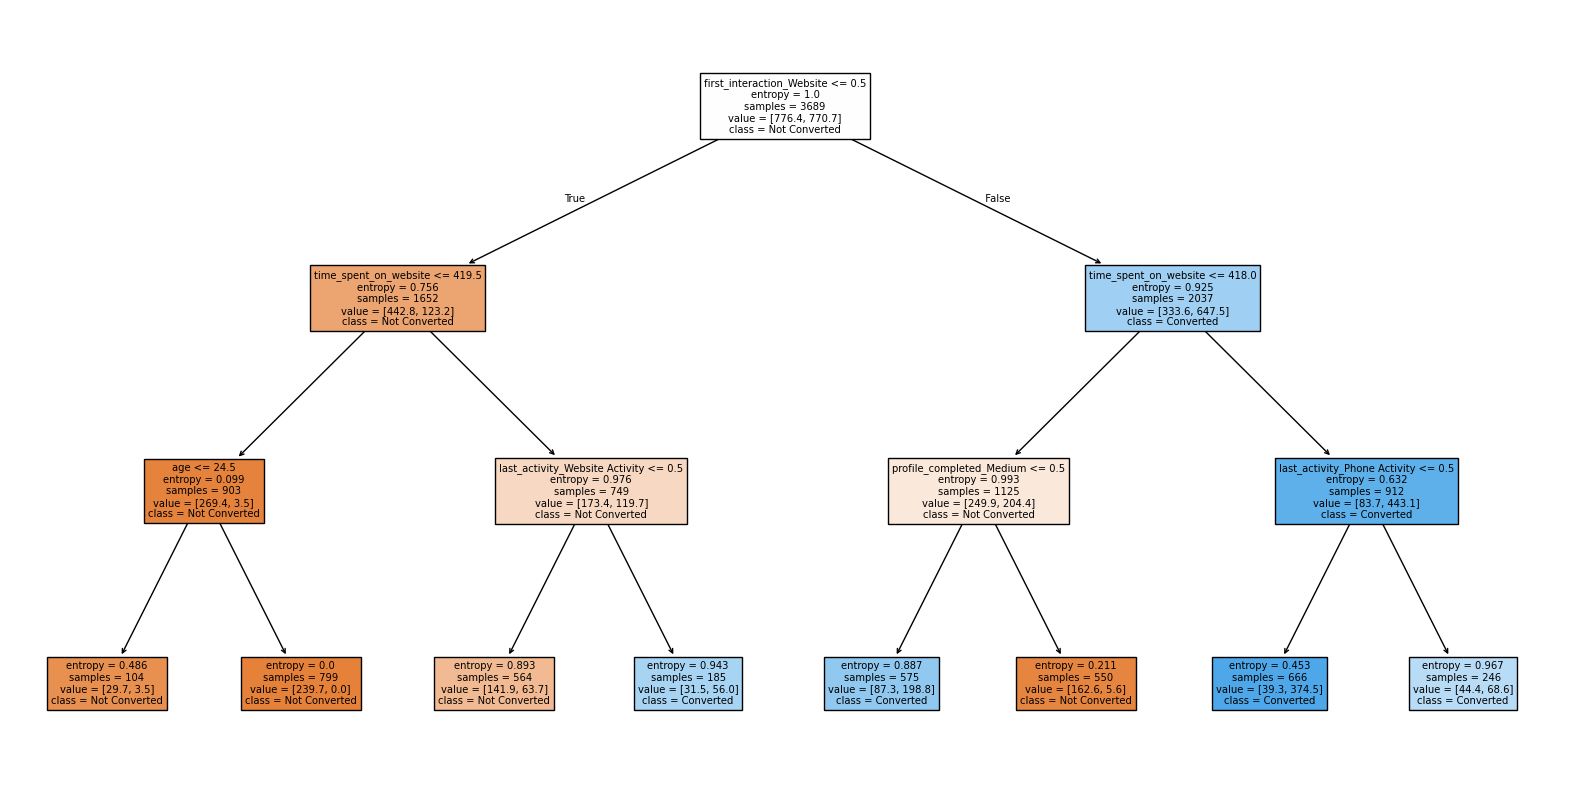

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
features=X_train.columns
plot_tree(
    d_tree_tuned,
    feature_names=features,
    class_names=['Not Converted', 'Converted'],
    filled=True
)

plt.show()

it appears that the first interaction was a website is an important feature to determine if someone converted or not. then how much time they spent on the website determined if they would convert or not

**next we will visualize the importance of each feature**

                                      Imp
time_spent_on_website            0.351252
first_interaction_Website        0.312102
profile_completed_Medium         0.238129
last_activity_Phone Activity     0.053203
last_activity_Website Activity   0.029287
age                              0.016026
website_visits                   0.000000
current_occupation_Unemployed    0.000000
page_views_per_visit             0.000000
current_occupation_Student       0.000000
current_occupation_Professional  0.000000
last_activity_Email Activity     0.000000
profile_completed_Low            0.000000
profile_completed_High           0.000000
print_media_type1_Yes            0.000000
print_media_type2_Yes            0.000000
digital_media_Yes                0.000000
educational_channels_Yes         0.000000
referral_Yes                     0.000000


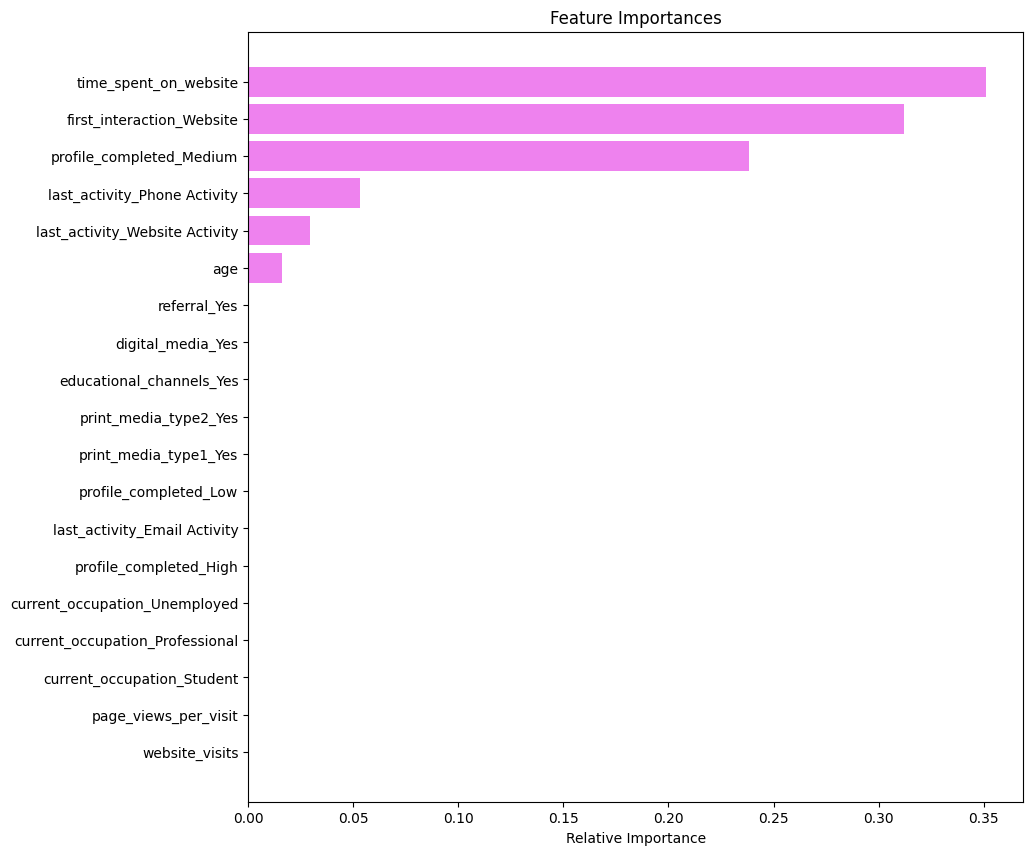

In [ ]:
# Importance of features in the tree building

print (pd.DataFrame(d_tree_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))
# Plotting the feature importance
importances = d_tree_tuned.feature_importances_

indices = np.argsort(importances)

plt.figure(figsize = (10, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

## Building a Random Forest model

In [ ]:
# Fitting the random forest tree classifier on the training data
rf_estimator = RandomForestClassifier(random_state = 13, criterion = "entropy")

rf_estimator.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=13)

## Model Performance evaluation and improvement

Accuracy: 0.9997289238275956

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2588
           1       1.00      1.00      1.00      1101

    accuracy                           1.00      3689
   macro avg       1.00      1.00      1.00      3689
weighted avg       1.00      1.00      1.00      3689



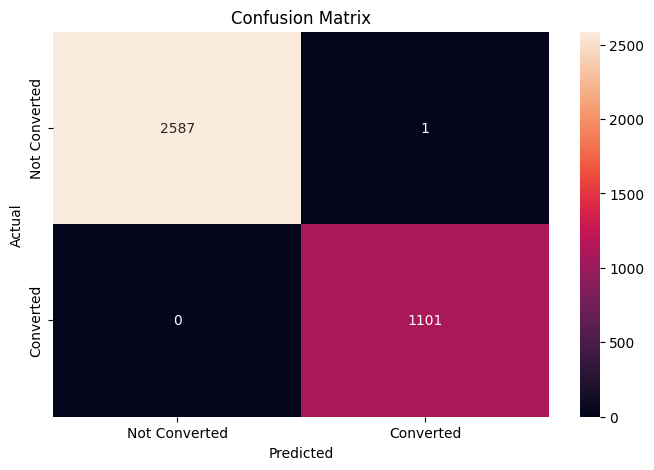

In [ ]:
# Checking performance on the training data
rf_y_pred_train = rf_estimator.predict(X_train)

metrics_score(y_train, rf_y_pred_train)

it is overfitting, let's not waste time with seeing how it did on the test data, let's go back and tune the parameters to counter the overfitting


**Random Forest Classifier - Hyperparameter Tuning**

In [ ]:

rf_estimator_tuned = RandomForestClassifier(random_state = 13, criterion = "entropy")
parameters = {
    "n_estimators": [100,110,120],
    "max_depth": [ 3, 4, 5],
    "min_samples_split": [ 20, 30],
    "min_samples_leaf": [ 5, 10],
    "class_weight": ["balanced",{0: 0.3, 1: 0.7}]
}

scorer = metrics.make_scorer(recall_score, pos_label=1)

grid_obj = GridSearchCV(
    rf_estimator_tuned,
    parameters,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

grid_obj.fit(X_train, y_train)

rf_estimator_tuned_base = grid_obj.best_estimator_

Accuracy: 0.855787476280835

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      2588
           1       0.71      0.87      0.78      1101

    accuracy                           0.86      3689
   macro avg       0.82      0.86      0.84      3689
weighted avg       0.87      0.86      0.86      3689



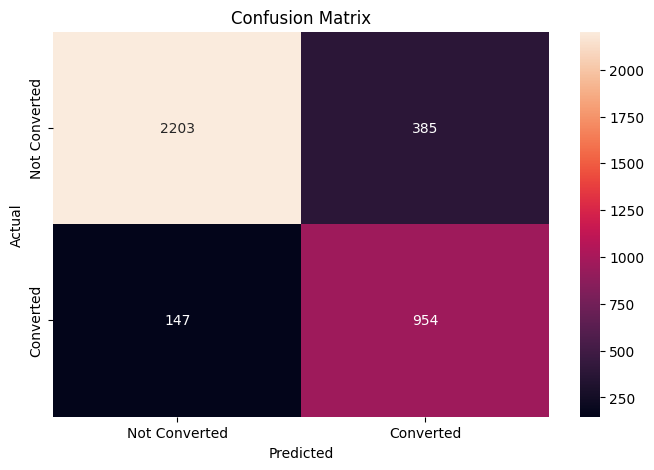

In [ ]:
# Checking performance on the training data
rf_y_pred_train_tuned = rf_estimator_tuned_base.predict(X_train)

metrics_score(y_train, rf_y_pred_train_tuned)

Accuracy: 0.8548212351029253

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       647
           1       0.72      0.85      0.78       276

    accuracy                           0.85       923
   macro avg       0.82      0.85      0.84       923
weighted avg       0.87      0.85      0.86       923



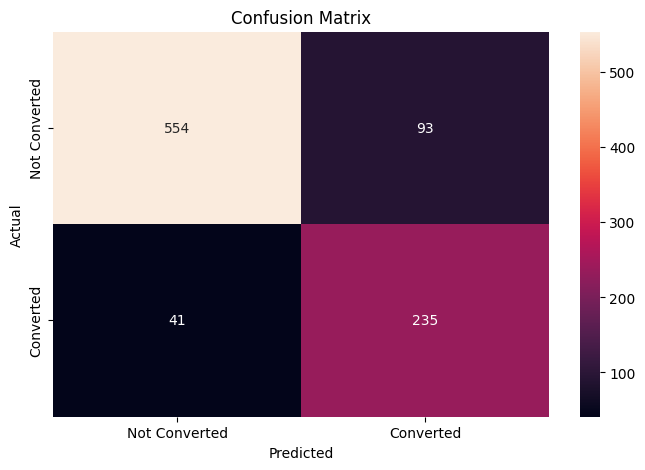

In [ ]:
# Checking performance on the test data
rf_y_pred_test_tuned = rf_estimator_tuned_base.predict(X_test)

metrics_score(y_test, rf_y_pred_test_tuned)

**Second tuned RF model**

In [ ]:
rf_estimator_tuned2 = RandomForestClassifier(random_state = 22, criterion = "entropy")
parameters = {
    "n_estimators": [100,110,120],
    "max_depth": [ 3, 4, 5,6,7],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [ 3, 5, 10],
    "class_weight": [ {0:0.2,1:0.8},{0: 0.3, 1: 0.7}]
}

scorer = metrics.make_scorer(recall_score, pos_label=1)

grid_obj = GridSearchCV(
    rf_estimator_tuned2,
    parameters,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

grid_obj.fit(X_train, y_train)

rf_estimator_tuned_base2 = grid_obj.best_estimator_

Accuracy: 0.7348875033884521

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.64      0.77      2588
           1       0.53      0.97      0.69      1101

    accuracy                           0.73      3689
   macro avg       0.75      0.80      0.73      3689
weighted avg       0.85      0.73      0.75      3689



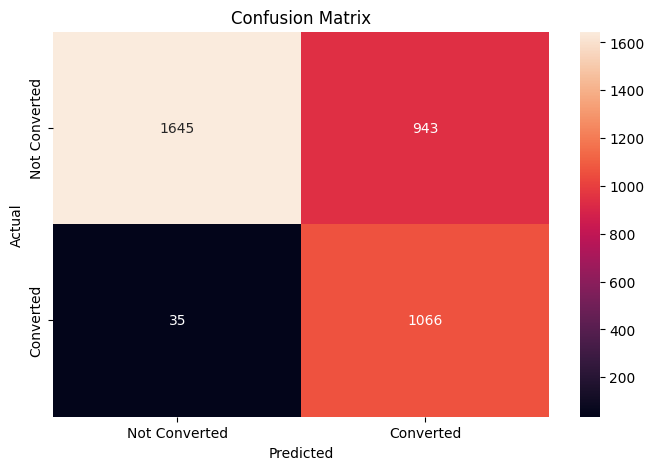

In [ ]:
# Checking performance on the training data
rf_y_pred_train_tuned2 = rf_estimator_tuned_base2.predict(X_train)

metrics_score(y_train, rf_y_pred_train_tuned2)

Accuracy: 0.7551462621885157

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.66      0.79       647
           1       0.55      0.97      0.70       276

    accuracy                           0.76       923
   macro avg       0.77      0.82      0.75       923
weighted avg       0.85      0.76      0.77       923



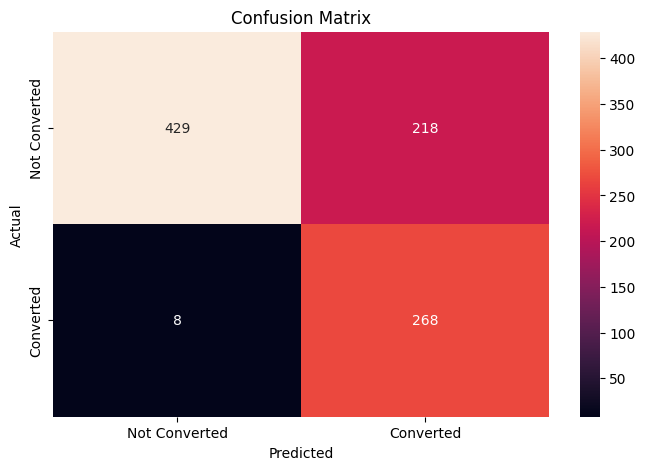

In [ ]:
# Checking performance on the test data
rf_y_pred_test_tuned2 = rf_estimator_tuned_base2.predict(X_test)

metrics_score(y_test, rf_y_pred_test_tuned2)

since we care more about getting potential conversions, recall was prioritized to minimize missed conversions. However, extremely high recall significantly reduced precision, increasing unnecessary outreach. Therefore, a balanced model was selected to maximize conversions while controlling marketing costs. the first tuned model is giving a better performance

**Check the feature importance in the first tuned model**

                                      Imp
first_interaction_Website        0.302265
time_spent_on_website            0.278361
profile_completed_High           0.114474
profile_completed_Medium         0.080923
last_activity_Phone Activity     0.042908
age                              0.040203
current_occupation_Professional  0.028256
current_occupation_Student       0.022941
last_activity_Website Activity   0.022713
page_views_per_visit             0.015232
website_visits                   0.011581
last_activity_Email Activity     0.011058
current_occupation_Unemployed    0.010706
referral_Yes                     0.007908
profile_completed_Low            0.006021
educational_channels_Yes         0.001462
digital_media_Yes                0.001342
print_media_type1_Yes            0.001104
print_media_type2_Yes            0.000544


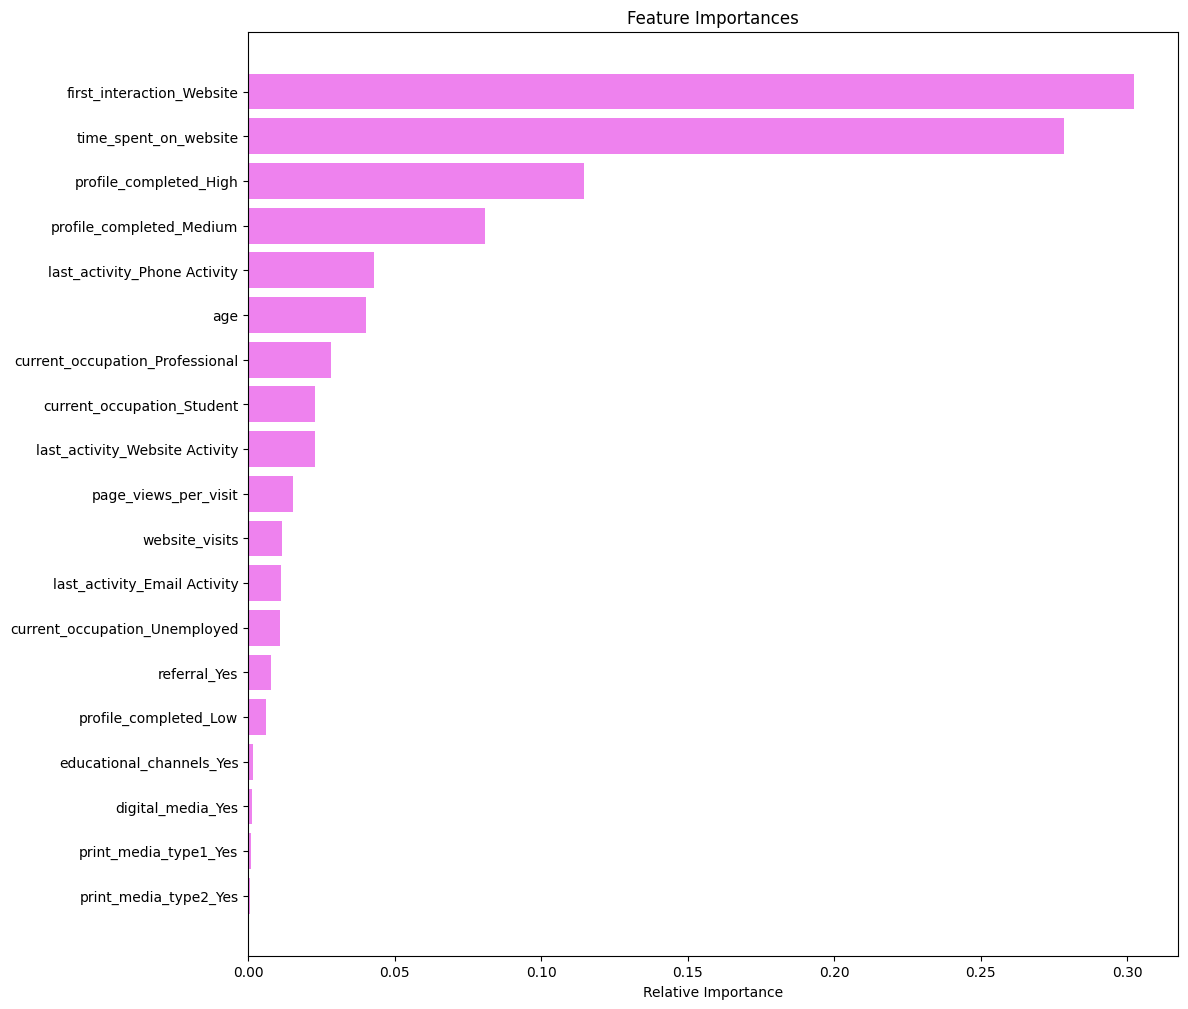

In [ ]:
# Importance of features in the tree building

print (pd.DataFrame(rf_estimator_tuned_base.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))
# build graph to show importance of features

importances = rf_estimator_tuned_base.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize = (12, 12))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

like in the decision tree we see that first interaction website and time spent on website are imporptant features. we also get here that profile completed high is an important feature. some secondary important features are last activity being on the phone, their age and occupation is either professional or student

## Actionable Insights and Recommendations

**Model Results**
Our predictive model identifies which leads are most likely to convert into paying customers. On the test set, it correctly recognized 85% of all actual paying customers (recall = 0.85), meaning very few potential customers are missed.

Of the leads the model flagged as likely to convert, 72% actually did convert (precision = 0.72), so some resources are spent on leads that don’t convert, but the trade-off is worthwhile because missing real customers is costlier.

Overall, the model strikes a good balance between catching as many converting leads as possible and avoiding too much wasted effort (F1 score = 0.78). This means sales teams can confidently focus on high-priority leads, improving efficiency and maximizing revenue.

In short, the model helps the company reach the right leads at the right time, capturing most potential customers while maintaining reasonable precision.



**Factors that drive customer conversions**
Engagement on the website (first contact and time spent) and profile completion are the strongest drivers of conversion. Traditional marketing channels (email, digital, print) have minimal impact after the lead is captured.

**Profile that leads to likely conversions**

First interaction: Website

Time spent on website: High (above average)

Profile completion: Medium or High

Recent activity: Phone or website interactions

Occupation: Student or older Professional (optional minor influence)



Leads matching this profile should be prioritized for outreach. These are the leads most likely to convert, maximizing ROI on sales and marketing efforts. Leads who don’t meet these criteria can be nurtured more slowly or through automated channels.
